# T2-prepared gradient echo

A conventional gradient echo does not refocus static dephasing, so its transverse signal decays at
$T_2^*$ rather than at $T_2$. $T_2^*$ contains the tissue's $T_2$ but adds everything static the
magnet and the tissue interfaces contribute, so it is magnet-dependent as well as
tissue-dependent — and at the short echo times a fast scan needs there is barely any decay at all.
Lengthening the echo time does not fix this: it weights by $T_2^*$, not by $T_2$.

A **$T_2$ preparation** adds controlled $T_2$ weighting before the readout begins:

```text
90x  ->  refocusing train  ->  -90x  ->  spoiler  ->  imaging train
     |<------ prep_time_s ----->|
```

The first pulse tips the magnetisation into the transverse plane, where it decays. A train of
refocusing pulses reverses static dephasing while it sits there, so what it decays at is $T_2$ and
not $T_2^*$. The tip-up returns what survives to the longitudinal axis, and a spoiler destroys
whatever is left transverse. The imaging train then reads **longitudinal** magnetisation that has
already been scaled by

$$S \;\propto\; e^{-\mathrm{prep\_time\_s} / T_2}$$

and it can be any fast readout at all, because the contrast is no longer its job.

`sc.modules.T2Prep` is that preparation. This notebook builds it, checks the emitted block, and
puts it in front of a shipped `GRE2D`.

| | |
|---|---|
| **1** | what the preparation is made of |
| **2** | simple and composite tip-up |
| **3** | `prep_time_s`, and the two instants it is measured between |
| **4** | the conditions the emitted block has to meet |
| **5** | composing it with a gradient echo — and the ordering that makes it work |
| **6** | the files |

**Output:** `.seq` files at preparation times of 0, 30, 50 and 80 ms with both tip-ups,
which [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) plays through a
Bloch simulator to recover $T_2$. **Needs nothing but `seqcraft`.**

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 220.0, 64, 5.0
PREP_TIMES_S = (0.0, 30e-3, 50e-3, 80e-3)
#: The two tip-ups the module offers.  `'simple'` is the default.
TIP_UPS = ('simple', 'composite_270_360')
#: The tip-down and the four composites of three: everything the two tip-ups share.
SHARED_PULSES = 13
VOXEL_MM = FOV_MM / MATRIX
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. What the preparation is made of

Fourteen hard pulses, and every one of them is played at the **same $B_1$ amplitude**:

```text
90x                                    the tip-down
(90x 180y 90x) x4                      four composite refocusing pulses
90(-x)                                 the tip-up: a net -90x, the tip-down undone
```

Each refocusing pulse is a **composite**: `90x 180y 90x`, three hard pulses that together perform
the 180. The four composites are phase-cycled in the **MLEV-4** pattern `+ + − −`. Composite
pulses and phase-cycled trains are used so that the imperfections of one pulse tend to cancel
against the next rather than accumulate down the train.

At a fixed amplitude a flip angle *is* a duration — a 90 is half a 180 — so `refocus_duration_s`
sets the 180's length and with it the amplitude every other pulse inherits. The module rounds the
**base 90** onto the RF raster rather than each pulse separately, which keeps the 1 : 2 : 3 : 4
duration ratio, and therefore the single amplitude, exact for any duration asked for.
`refocus_duration_s` reports the 180 it realised and `requested_refocus_duration_s` keeps the
request.

The refocusing train is what makes this a $T_2$ preparation rather than a $T_2^*$ one.

In [2]:
prep = sc.modules.T2Prep(opts=opts, prep_time_s=50e-3, spoil_voxel_mm=VOXEL_MM)

print(f'{len(prep.pulses)} pulses, all at B1 = {prep.b1_hz:.0f} Hz '
      f'= {sc.convert(prep.b1_hz, "Hz", "uT"):.1f} uT\n')
print(f'{"#":>3} {"flip / deg":>11} {"phase / deg":>12} {"duration / us":>14}')
for index, rf in enumerate(prep.pulses):
    flip = float(np.abs(np.trapezoid(rf.signal, rf.t)) * 360.0)
    print(f'{index:3d} {flip:11.0f} {np.rad2deg(rf.phase_offset) % 360.0:12.0f} '
          f'{float(pp.calc_duration(rf)) * 1e6:14.0f}')

14 pulses, all at B1 = 500 Hz = 11.7 uT

  #  flip / deg  phase / deg  duration / us
  0          90            0            630
  1          90            0            630
  2         180           90           1130
  3          90            0            630
  4          90            0            630
  5         180           90           1130
  6          90            0            630
  7          90          180            630
  8         180          270           1130
  9          90          180            630
 10          90          180            630
 11         180          270           1130
 12          90          180            630
 13          90          180            630


---
## 2. Simple and composite tip-up

The tip-up returns the surviving transverse magnetisation to $+z$. `T2Prep` offers two ways to
build it, both a net $-90$ about $+x$:

```text
tip_up='simple'               -90x                        the default
tip_up='composite_270_360'    +270x followed by -360x
```

They also differ in where `prep_time_s` ends — the $-90$'s centre in one case, the $270$'s centre
in the other — and in RF cost.

In [3]:
print(f'{"tip_up":>19} {"pulses":>7}  {"the tip-up, flip@phase":<24}'
      f'{"block / ms":>11} {"prep_time_s / ms":>18}')
for name in TIP_UPS:
    made = sc.modules.T2Prep(opts=opts, prep_time_s=50e-3, tip_up=name, spoil_voxel_mm=VOXEL_MM)
    written = '  '.join(
        f'{np.abs(np.trapezoid(rf.signal, rf.t)) * 360.0:3.0f}@{np.rad2deg(rf.phase_offset) % 360.0:3.0f}'
        for rf in made.pulses[SHARED_PULSES:])
    print(f'{name:>19} {len(made.pulses):7d}  {written:<24}{made().duration * 1e3:11.2f} '
          f'{made.prep_time_s * 1e3:18.3f}')

             tip_up  pulses  the tip-up, flip@phase   block / ms   prep_time_s / ms
             simple      14   90@180                       51.59             50.000
  composite_270_360      15  270@  0  360@180              54.22             50.000


Two pulses instead of one, and about 2.6 ms more RF, which inside a preparation is paid in
relaxation. The simple form is the default for that reason.

Composite pulses are generally reached for to reduce sensitivity to flip-angle error, and
[`02`](02_simulate_and_reconstruct.ipynb) compares the two under $B_1$ and $B_0$ offsets. In this
protocol it finds no consistent advantage for the composite form.

Everything else is the same either way: the four-part structure, the MLEV-4 refocusing train, the
single $B_1$, the spoiler outside the interval, and what `prep_time_s` measures — which is the
next section.

---
## 3. `prep_time_s`, and the two instants it is measured between

The preparation time is the interval the magnetisation spends **transverse**: from the centre of
the tip-down to the centre of the tip-up. That is the interval the exponential is over.

| the interval ends at | |
|---|---|
| `tip_up='simple'` | the centre of the $-90$ |
| `tip_up='composite_270_360'` | the centre of the $270$ |

Every RF group starts on the gradient raster, because the seam between two consecutive pulses is
where a block boundary has to be cut and only raster instants can be cut. So the placement is
quantised first and `prep_time_s` is **measured off it**, within half a raster of the request.

The compiled sequences print warnings from the imaging train rather than from the preparation:
blocks over the **vector-norm** gradient limit, which the compiler reports as legal on a real
amplifier because no single physical axis exceeds its own. They are collected and summarised in
section 6 rather than printed once per file.

In [4]:
print(f'{"requested / ms":>15} {"realised / ms":>14} {"tip-down at":>13} {"tip-up at":>11}')
for prep_time_s in PREP_TIMES_S[1:]:
    made = sc.modules.T2Prep(opts=opts, prep_time_s=prep_time_s, spoil_voxel_mm=VOXEL_MM)
    print(f'{prep_time_s * 1e3:15.1f} {made.prep_time_s * 1e3:14.4f} '
          f'{made.time_to_tip_down() * 1e3:12.3f}m {made.time_to_tip_up() * 1e3:10.3f}m')
print()
print(f'the shortest these pulses leave room for is {prep.min_prep_time_s * 1e3:.2f} ms, and a '
      f'shorter request is refused')

 requested / ms  realised / ms   tip-down at   tip-up at
           30.0        30.0000        0.350m     30.350m
           50.0        50.0000        0.350m     50.350m
           80.0        80.0000        0.350m     80.350m

the shortest these pulses leave room for is 12.08 ms, and a shorter request is refused


Every group starts on the gradient raster, so the realised interval is what the sequence
delivers rather than what was requested.

---
## 4. The conditions the emitted block has to meet

Three conditions, all read back from the emitted events.

**The gaps either side of every refocusing pulse must be equal.** Static dephasing accumulated
before a refocusing pulse is undone only if the same time passes after it. That is why the four
composites sit at 1/8, 3/8, 5/8 and 7/8 of the preparation: the four inner gaps are equal and the
two outer ones are half of each.

**No gradient may play while the magnetisation is transverse.** A gradient there would dephase
what the preparation is storing. The only gradient in the block is the spoiler, after the tip-up.

**The tip-up must return the prepared magnetisation toward $+z$.** A single $90$ about $-x$ is the
tip-down undone; $270$ about $+x$ then $360$ about $-x$ is the same net rotation built
differently. With a sign wrong the tip-up continues the rotation instead of reversing it, the
prepared magnetisation is spoiled rather than stored, and the sequence still compiles.

In [5]:
gaps = np.array(prep.interval_gaps_s) * 1e3
print('intervals between consecutive rotation instants, ms:')
print('   tip-down -> 1st     ', f'{gaps[0]:8.3f}')
for index in range(1, len(gaps) - 1):
    print(f'   {index} -> {index + 1}               ', f'{gaps[index]:8.3f}')
print('   4th -> tip-up       ', f'{gaps[-1]:8.3f}')
half = gaps[1:-1].mean() / 2.0
print(f'\ninner gaps agree to {np.ptp(gaps[1:-1]) * 1e3:.1f} us; the outer two are within '
      f'{max(abs(gaps[0] - half), abs(gaps[-1] - half)) * 1e3:.1f} us of half of them')

moments = sc.moments(prep(), 0)
print(f'\nthe only gradient in the block is the spoiler: {moments}')
print(f'it starts at {prep.time_to_spoiler() * 1e3:.2f} ms, after the tip-up at '
      f'{prep.time_to_tip_up() * 1e3:.2f} ms')

intervals between consecutive rotation instants, ms:
   tip-down -> 1st         6.250
   1 -> 2                  12.500
   2 -> 3                  12.500
   3 -> 4                  12.500
   4th -> tip-up           6.250

inner gaps agree to 0.0 us; the outer two are within 0.0 us of half of them

the only gradient in the block is the spoiler: {'z': 1163.6363636363571}
it starts at 50.63 ms, after the tip-up at 50.35 ms


---
## 5. Composing it with a gradient echo

A complete acquisition is the preparation, then a readout train, then enough recovery time before
the next shot.

**The line ordering matters.** What the preparation stores is longitudinal magnetisation, and
after the tip-up longitudinal recovery begins at $T_1$. The contrast of the image is set by the
centre of k-space, so every millisecond between the tip-up and the acquisition of k = 0 is a
millisecond of recovery washing the preparation out.

A linear ordering reaches the centre halfway through the train. A **centric** ordering reaches it
first, and therefore preserves more of the prepared contrast.

In [6]:
gre = sc.modules.GRE2D(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                       thickness_mm=THICKNESS_MM, flip_deg=15.0)
LINEAR = list(range(MATRIX))
CENTRIC = sorted(range(MATRIX), key=lambda line: (abs(line - gre.center_line),
                                                  line >= gre.center_line))

print(f'GRE2D: TE {gre.tr.te_s * 1e3:.2f} ms, TR {gre.tr.tr_s * 1e3:.2f} ms, '
      f'train {gre(lines=LINEAR).duration * 1e3:.0f} ms')
print(f'centric order begins {CENTRIC[:6]} ... centre line is {gre.center_line}')
print()
print(f'{"ordering":>10} {"k = 0 reached after":>21} {"T1 = 1200 ms leaves":>21}')
for name, order in (('linear', LINEAR), ('centric', CENTRIC)):
    delay_s = gre.time_to_center_line(lines=order)
    print(f'{name:>10} {delay_s * 1e3:20.1f}m {np.exp(-delay_s / 1.2) * 100:20.0f} %')

GRE2D: TE 4.62 ms, TR 9.65 ms, train 618 ms
centric order begins [32, 31, 33, 30, 34, 29] ... centre line is 32

  ordering   k = 0 reached after   T1 = 1200 ms leaves
    linear                315.0m                   77 %
   centric                  6.2m                   99 %


Three hundred milliseconds of $T_1$ recovery is most of the preparation thrown away, so this
acquisition uses the centric ordering.

---
## 6. The files

Both tip-ups are written out at every preparation time, because `02` compares them. The
unprepared control at 0 ms has no tip-up, so it is written once.

In [7]:
def shot(prep_time_s, tip_up='simple'):
    """One shot: the preparation, then a centrically ordered gradient echo."""
    tree = sc.LogicBlock('t2prep_gre')
    if not prep_time_s:
        tree.add(0.0, gre(lines=CENTRIC))
        return None, tree
    made = sc.modules.T2Prep(opts=opts, prep_time_s=prep_time_s, tip_up=tip_up,
                             spoil_voxel_mm=VOXEL_MM)
    tree.add(0.0, made())
    tree.add(float(raster.ceil(made().duration)), gre(lines=CENTRIC))
    return made, tree


def stem(prep_time_s, tip_up):
    """The file name, which carries the tip-up whenever there is one to carry."""
    name = f't2prep_gre_2d_{int(round(prep_time_s * 1e3)):03d}'
    return name if not prep_time_s else f'{name}_{tip_up}'


print(f'{"prep / ms":>10} {"tip_up":>19} {"realised":>10} {"shot / ms":>11} {"blocks":>8}')
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    for prep_time_s in PREP_TIMES_S:
        for tip_up in (TIP_UPS if prep_time_s else TIP_UPS[:1]):
            made, tree = shot(prep_time_s, tip_up)
            name = stem(prep_time_s, tip_up)
            seq = sc.compile(tree, opts, name=name, definitions={
                'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
                'prep_time_s': 0.0 if made is None else made.prep_time_s,
            })
            seq.write(str(SEQ_DIR / f'{name}.seq'))
            realised = '-' if made is None else f'{made.prep_time_s * 1e3:.3f}'
            print(f'{prep_time_s * 1e3:10.0f} {"-" if made is None else tip_up:>19} '
                  f'{realised:>10} {tree.duration * 1e3:11.2f} {len(seq.block_events):8d}')

print(f'\n{len(caught)} warnings, every one of them from the GRE2D train:')
for kind in sorted({str(w.message).split(':')[0] for w in caught}):
    print(f'   {kind}')

np.savez(SEQ_DIR / 't2prep_gre_2d_nominal.npz',
         matrix=np.array([MATRIX, MATRIX]), fov_mm=np.array([FOV_MM, FOV_MM]),
         thickness_mm=THICKNESS_MM, lines=np.array(CENTRIC),
         center_line=gre.center_line, prep_times_s=np.array(PREP_TIMES_S),
         tip_ups=np.array(TIP_UPS), te_s=gre.tr.te_s, tr_s=gre.tr.tr_s)
print(f'\n-> {SEQ_DIR / "t2prep_gre_2d_nominal.npz"}')

 prep / ms              tip_up   realised   shot / ms   blocks


         0                   -          -      617.60      256


        30              simple     30.000      649.19      276
        30   composite_270_360     30.000      651.82      277


        50              simple     50.000      669.19      276


        50   composite_270_360     50.000      671.82      277


        80              simple     80.000      699.19      276


        80   composite_270_360     80.000      701.82      277

7 warnings, every one of them from the GRE2D train:
   192 blocks over the vector-norm limit (legal on real amplifiers)

-> seq/t2prep_gre_2d_nominal.npz


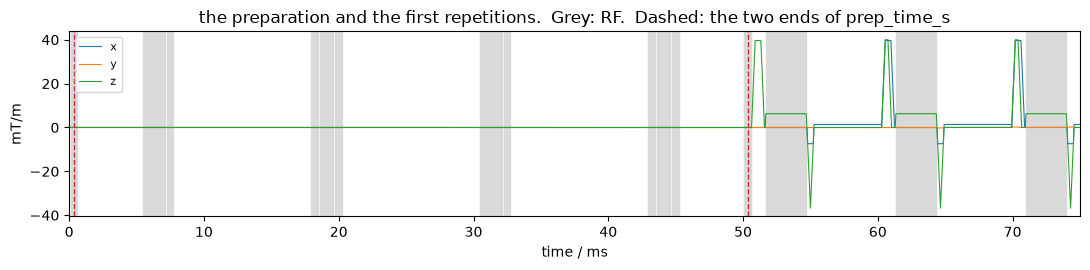

In [8]:
made, tree = shot(50e-3)
grid, grads, spans = sc.sample(tree, opts)
fig, ax = plt.subplots(figsize=(11.0, 2.8))
for axis in ('x', 'y', 'z'):
    if axis in grads:
        ax.plot(grid * 1e3, grads[axis] / 42.576e6 * 1e3, lw=0.8, label=axis)
for kind, start, stop, _path in spans:
    if kind == 'rf':
        ax.axvspan(start * 1e3, stop * 1e3, color='0.85', zorder=0)
ax.axvline(made.time_to_tip_down() * 1e3, color='C3', ls='--', lw=1.0)
ax.axvline(made.time_to_tip_up() * 1e3, color='C3', ls='--', lw=1.0)
ax.set(xlim=(0, 75), xlabel='time / ms', ylabel='mT/m',
       title='the preparation and the first repetitions.  Grey: RF.  '
             'Dashed: the two ends of prep_time_s', )
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()

Between the dashed lines there are fourteen grey bands and **no gradient at all** — which is the
preparation working. The single gradient after them is the spoiler, and the imaging train starts
after that.

---
## Summary

| | |
|---|---|
| **what it buys** | controlled $T_2$ weighting before the gradient-echo readout, as a factor $e^{-\mathrm{prep\_time\_s}/T_2}$ on the longitudinal magnetisation |
| **how** | tip down, refocus while it decays, tip back up, spoil what is left |
| **the refocusing train** | four `90x 180y 90x` composites at 1/8, 3/8, 5/8 and 7/8, phase-cycled MLEV-4 `+ + − −`, so the gaps either side of each are equal |
| **one $B_1$** | every pulse shares it; the base 90 is what lands on the raster, so the ratio is exact for any `refocus_duration_s` |
| **`prep_time_s`** | the transverse interval, between two RF centres, realised to within half a gradient raster |
| **the tip-up** | `'simple'` by default, `'composite_270_360'` on request; the choice moves the second endpoint |
| **no gradient inside** | the only one in the block is the spoiler, after the tip-up |
| **line ordering** | centric, because $T_1$ recovery between the tip-up and k = 0 erodes the contrast |

**What this notebook does not cover.** [`02`](02_simulate_and_reconstruct.ipynb) uses a Bloch
simulation to measure the resulting $T_2$ weighting. **No quantitative $B_0$ or $B_1$ robustness
is claimed for either tip-up.** `02` compares them under illustrative offsets; a quantitative
tolerance would need a broader characterisation. Adiabatic $T_2$ preparation is a separate design
family intended for broader $B_0$/$B_1$ robustness.

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §17.4 — the preparation, its non-selectivity, the `+90` / refocusing / `-90` / spoiler
  structure, and why the imaging that follows is ordered centrically.
- M. H. Levitt and R. Freeman, "NMR population inversion using a composite pulse",
  *J. Magn. Reson.* **33**, 473 (1979); and *J. Magn. Reson.* **43**, 65 (1981) — composite pulses
  and the MLEV cycles.
- J. H. Brittain et al., "Coronary angiography with magnetization-prepared T2 contrast",
  *Magn. Reson. Med.* **33**, 689 (1995).